In [8]:
import rasterio
import numpy as np
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from gym import Env
from gym.spaces import Discrete, Box
from skimage.util import view_as_blocks

In [9]:
with rasterio.open('South_Clear_Creek/Lidar_DEM_Hillshade/South_Clear_Creek_BareEarth_DEM_1m.tif') as elev_src:
    elevation_unstandard = np.flipud(elev_src.read(1))  # Flip if origin is bottom-left
    height, width = elevation_unstandard.shape
    
with rasterio.open('South_Clear_Creek/Roads_Boundary/South_Clear_Creek_Roads_Mask.tif') as mask_src:
    path_mask = np.flipud(mask_src.read(1))

In [10]:
from sklearn.preprocessing import StandardScaler

elevation = StandardScaler().fit_transform(elevation_unstandard)

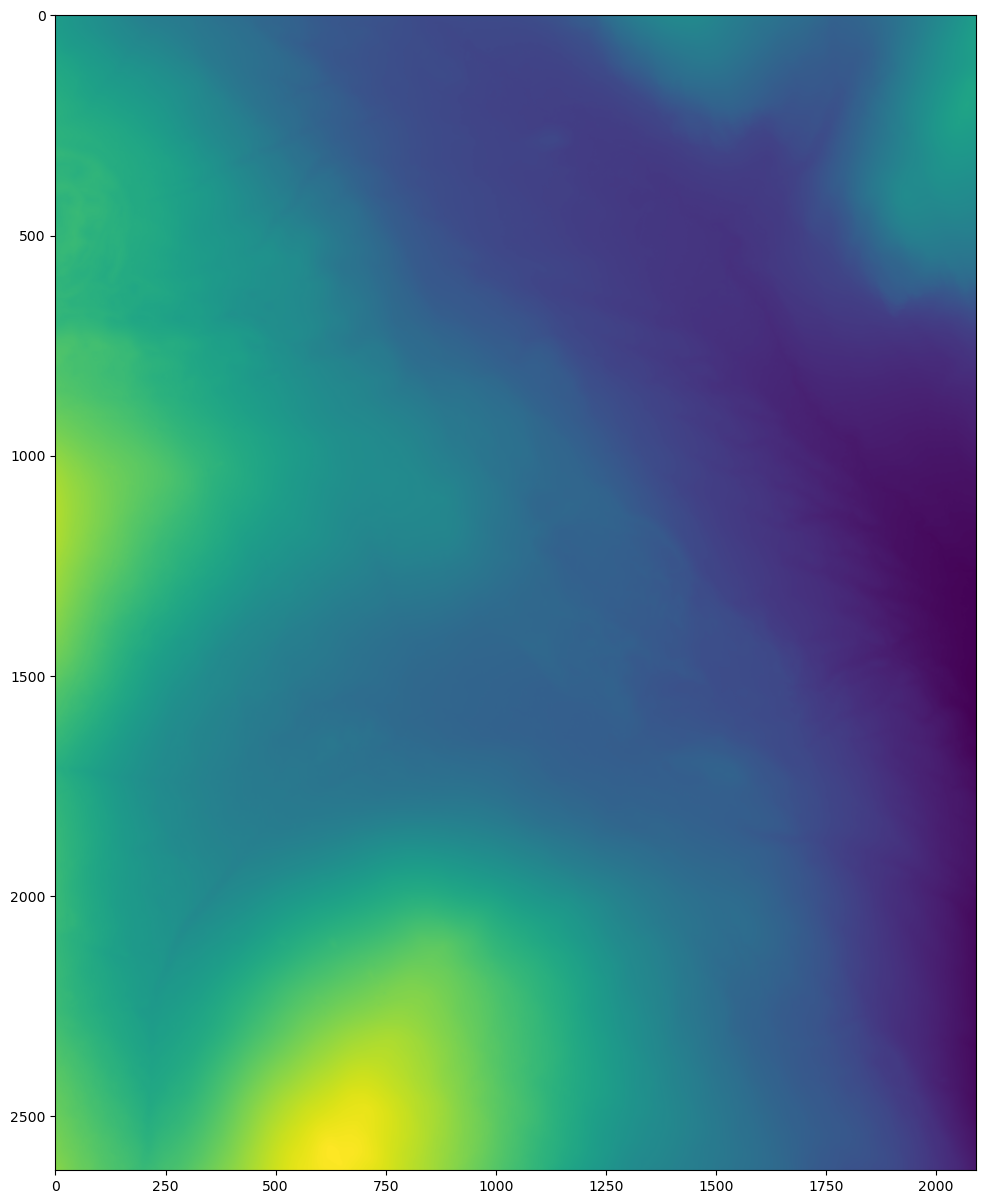

In [11]:
# Example of how could have tiled data for better training
tiles = view_as_blocks(elevation_unstandard, (2623, 2092))

plt.figure(figsize=(15, 15))
plt.imshow(tiles[2, 1])
plt.show()

In [5]:
tiles_all = split_to_tiles(elevation, 5)
print(tiles.shape)
tiles = tiles_all[:, :, :1, :]


(2623, 2092, 5, 5)


In [4]:
import numpy as np
from gymnasium import Env
from gymnasium.spaces import Discrete, Box

class RobotEnv(Env):
    def __init__(self, elevation, path_mask):
        super(RobotEnv, self).__init__()
        self.speed = 25
        self.elevation = elevation.astype(np.float32)
        self.path_mask = path_mask.astype(np.uint8)
        self.height, self.width = elevation.shape
        self.robot = [self.width // 2, self.height // 2, 10, 10]
        self.target = [int(self.width * 0.7), int(self.height * 0.7)]
        self.max_steps = 250
        self.action_space = Discrete(5)  # 0=Left, 1=Right, 2=Up, 3=Down, 4=Stay
        self.observation_space = Box(
            low=np.array([0, 0, elevation.min(), 0], dtype=np.float32),
            high=np.array([self.width, self.height, elevation.max(), 1], dtype=np.float32),
            dtype=np.float32
        )
        self.step_count = 0
        self.path_history = []

    def _get_observation(self):
        x = int(self.robot[0] + self.robot[2] / 2)
        y = int(self.robot[1] + self.robot[3] / 2)
        elev = self.elevation[y, x]
        on_path = self.path_mask[y, x]
        return np.array([x, y, elev, on_path], dtype=np.float32)

    def reset(self, seed=None, options=None):
        self.robot = [self.width // 2, self.height // 2, 10, 10]
        self.step_count = 0
        self.path_history = [self.robot[:2]]
        return self._get_observation(), {}

    def step(self, action):
        self.step_count += 1
        old_x, old_y = int(self.robot[0]), int(self.robot[1])


        prev_distance = np.linalg.norm(np.array([old_x, old_y]) - np.array(self.target))

        if action == 0:  # Left
            new_x = max(0, self.robot[0] - self.speed)
            new_y = self.robot[1]
        elif action == 1:  # Right
            new_x = min(self.width - self.robot[2], self.robot[0] + self.speed)
            new_y = self.robot[1]
        elif action == 2:  # Up
            new_x = self.robot[0]
            new_y = max(0, self.robot[1] - self.speed)
        elif action == 3:  # Down
            new_x = self.robot[0]
            new_y = min(self.height - self.robot[3], self.robot[1] + self.speed)
        else:  # Stay
            new_x, new_y = self.robot[0], self.robot[1]

        new_x, new_y = int(new_x), int(new_y)
        self.robot[0], self.robot[1] = new_x, new_y
        self.path_history.append((new_x, new_y))  # Track movement

        pos = np.array([self.robot[0] + self.robot[2] / 2, self.robot[1] + self.robot[3] / 2], dtype=np.float32)
        distance = np.linalg.norm(pos - self.target)


        elev_change = abs(self.elevation[new_y, new_x] - self.elevation[old_y, old_x])


        reward = -distance / 100  
        reward += 10 * np.exp(-elev_change / 10) 
        if self.path_mask[new_y, new_x]:
            reward += 1  
        if distance < 150:
            reward += 50  


        if distance < prev_distance:
            reward += 5  
        else:
            reward -= 5 

        reward = np.clip(reward, -100, 100)

        done = distance < 50 or self.step_count >= self.max_steps
        truncated = self.step_count >= self.max_steps

        return self._get_observation(), reward, done, truncated, {}

    def render(self):
        """ Visualize the elevation map with path overlay """
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))

        # Plot elevation map
        plt.imshow(self.elevation, cmap='terrain', origin='upper')
        plt.colorbar(label="Elevation")

        # Extract x, y path history
        x_vals, y_vals = zip(*self.path_history)
        plt.plot(x_vals, y_vals, marker='o', color='red', markersize=2, linewidth=1, label="Agent Path")

        # Plot start position
        plt.scatter(self.path_history[0][0], self.path_history[0][1], c='green', s=100, label="Start")

        # Plot target position
        plt.scatter(self.target[0], self.target[1], c='blue', s=100, label="Target")

        plt.title("Robot Path Over Elevation Map")
        plt.legend()
        plt.show()


In [5]:
from stable_baselines3 import PPO
env = RobotEnv(elevation, path_mask)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)



2025-03-29 21:49:39.077432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 250       |
|    ep_rew_mean     | -5.84e+03 |
| time/              |           |
|    fps             | 2136      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 250         |
|    ep_rew_mean          | -5.31e+03   |
| time/                   |             |
|    fps                  | 1568        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015685285 |
|    clip_fraction        | 0.227       |
|    clip_range           | 0.2         |
|    entro

In [11]:
model.save("PPOF")

In [6]:
from stable_baselines3 import PPO
model = PPO.load("PPOF")


2025-03-29 21:46:00.159875: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


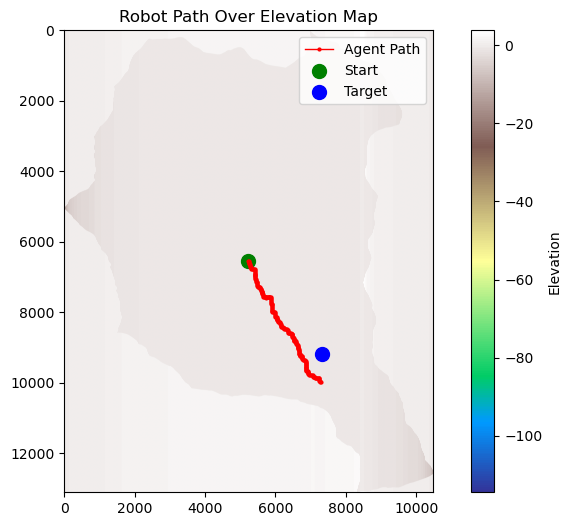

In [11]:
env = RobotEnv(elevation, path_mask)
obs, _ = env.reset()
done = False

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, truncated, _ = env.step(action)

env.render()

In [10]:
def generate_random_locations(width, height, num_tests=5):
    
    random_positions = []
    for _ in range(num_tests):
        x = np.random.randint(0, width)
        y = np.random.randint(0, height)
        random_positions.append((x, y))
    return random_positions

# Example usage
width = 100  # Assume your grid width is 100
height = 100  # Assume your grid height is 100
random_locations = generate_random_locations(width, height)

print("Random test locations:", random_locations)

Random test locations: [(90, 92), (56, 90), (22, 92), (16, 24), (61, 45)]
